In [2]:
from dataset import CUBSentences

In [3]:
data = CUBSentences(root_data_dir='/Users/agathe/dev/data', split='train')

In [4]:
sample, length = data[2][0], data[2][1]

In [5]:
print("lenght is ", length)
for i in sample:
    print(data.i2w[str(i)])

lenght is  17
this
bird
has
a
curved
white
bill
,
a
white
belly
,
and
black
primaries
.
<eos>
<pad>
<pad>
<pad>
<pad>
<pad>
<pad>
<pad>
<pad>
<pad>
<pad>
<pad>
<pad>
<pad>
<pad>
<pad>


In [6]:
data = CUBSentences(root_data_dir='/Users/agathe/dev/data', split='train', one_hot=True)

In [7]:
data[0][0].shape

torch.Size([32, 1590])

In [44]:
for i in range(10):
    print(data._to_string(data[i][0].numpy()))

a white bird with black tipped wings and a long grey beak . <eos> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad>
this bird has a white chest with a long pointed white beak . <eos> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad>
this bird has a curved white bill , a white belly , and black primaries . <eos> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad>
this white bird has black along the ends of its wings and a pale , long beak . <eos> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad>
this medium sized to large bird has a white belly , breast , head and tail with a long , pointed beak . <eos> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad>
the bird has a long white bill and long black secondaries . <eos> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad

In [14]:
from torchvision import transforms, datasets
tx = transforms.Compose([transforms.Resize([64, 64]), transforms.ToTensor()])
image_data = datasets.ImageFolder('/Users/agathe/dev/data/cub/train', transform=tx)
            

In [16]:
image_data[0][0].shape

torch.Size([3, 64, 64])

In [40]:
len(data), len(image_data)

(88550, 8855)

Chaque image est associée à 10 légendes possibles donc le jeu de données final est fabriqué en répliquant 10 fois chaque image.
pour l'indice i on renvoie l'image i//10

In [1]:
from dataset import CUB

dataset = CUB('/home/asenella/scratch/data/')

/home/asenella/miniconda3/envs/multivaenv/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/home/asenella/miniconda3/envs/multivaenv/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [2]:
dataset[0].data['text']

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 1., 0.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.]])

In [3]:
from architectures_text import Enc

encoder = Enc(latentDim_w=0,latentDim_z=12,dist='normal')



/home/asenella/dev/multivae_package/expes/cub/architectures_text.py:112: SyntaxWarning: "is not" with a literal. Did you mean "!="?
  self.joint_decoder_input_dim = fBase*8 if latentDim_w is not 0 else fBase*4
/home/asenella/miniconda3/envs/multivaenv/lib/python3.10/site-packages/torch/nn/init.py:453: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


In [4]:
sample = dataset[0].data['text'].reshape(1,32,1590)

In [5]:
embedding = encoder(sample)
embedding

ModelOutput([('embedding',
              tensor([[-0.1766, -0.4262, -0.3309,  0.1961,  0.2472,  0.0552,  0.4888,  0.1221,
                        0.8287,  0.2071,  0.0742,  0.0395]], grad_fn=<UnsqueezeBackward0>)),
             ('style_embedding',
              tensor([], size=(1, 0), grad_fn=<AddmmBackward0>)),
             ('log_covariance',
              tensor([[1.0000e-20, 1.0000e-20, 1.0000e-20, 1.0000e-20, 1.0000e-20, 1.0000e-20,
                       1.0000e-20, 1.0000e-20, 1.0000e-20, 1.0000e-20, 1.0000e-20, 1.0000e-20]],
                     grad_fn=<AddBackward0>)),
             ('style_log_covariance',
              tensor([], size=(1, 0), grad_fn=<AddBackward0>))])

In [6]:
from architectures_text import Dec
import torch

decoder = Dec(0,12)

joint_embedding = torch.cat((embedding.style_embedding,embedding.embedding), dim=-1)
joint_embedding.shape

torch.Size([1, 12])

In [7]:
recon = decoder(joint_embedding)

In [8]:

from architectures_image import EncoderImg, DecoderImg

encoder_image = EncoderImg(0,12,'normal')

embedding = encoder_image(dataset[0].data['image'].unsqueeze(0))

embedding.embedding.shape

torch.Size([1, 12])

In [9]:
decoder_image = DecoderImg(12)

decoder_image(joint_embedding)

ModelOutput([('reconstruction',
              tensor([[[[ 1.7236e-02,  4.3571e-02,  4.4164e-02,  ...,  5.2802e-02,
                          5.3032e-02,  5.4813e-02],
                        [-1.0322e-02,  1.3973e-02,  1.4271e-02,  ...,  7.9445e-02,
                          7.9875e-02,  7.1400e-02],
                        [-1.0418e-02,  1.4032e-02,  1.4122e-02,  ...,  7.9327e-02,
                          8.0052e-02,  7.1399e-02],
                        ...,
                        [-3.6751e-02, -8.6115e-03, -8.6325e-03,  ...,  8.9194e-02,
                          8.9916e-02,  5.8973e-02],
                        [-3.6611e-02, -8.4362e-03, -8.2640e-03,  ...,  8.9569e-02,
                          9.0094e-02,  5.8899e-02],
                        [-3.2492e-02, -1.9762e-02, -1.9577e-02,  ...,  8.2058e-02,
                          8.2477e-02,  5.3541e-02]],
              
                       [[ 3.4775e-03, -1.4893e-02, -1.5398e-02,  ...,  3.1998e-03,
                          3.03

In [10]:
from multivae.models import JNF, JNFConfig

model_config = JNFConfig(
    n_modalities = 2,
    latent_dim = 12,
    decoders_dist=dict(image = 'laplace',text = 'categorical'),
    warmup=10
)


model=JNF(model_config=model_config,
                encoders = dict(image = EncoderImg(0,model_config.latent_dim,dist='normal'),
                                text = Enc(0,model_config.latent_dim,dist='normal')),
                
                decoders=dict(
                    image = DecoderImg(model_config.latent_dim),
                    text = Dec(0,model_config.latent_dim)
                )
                
                )




/home/asenella/miniconda3/envs/multivaenv/lib/python3.10/site-packages/torch/nn/init.py:453: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


In [11]:
from torch.utils.data import DataLoader

dataloader = DataLoader(dataset,batch_size=32)

sample = next(iter(dataloader))

model(sample)

ModelOutput([('loss', tensor(14415.5811, grad_fn=<DivBackward0>)),
             ('metrics',
              {'kld_prior': tensor(0.4557, grad_fn=<MulBackward0>),
               'recon_loss': tensor(14415.5664, grad_fn=<DivBackward0>),
               'ljm': 0})])

In [13]:
import matplotlib.pyplot as plt
import numpy as np

def plot_text_as_image_tensor(sentences_lists_of_words, pixel_width=64, pixel_height=384):
    imgs = []
    for sentence in sentences_lists_of_words:
        px = 1 / plt.rcParams['figure.dpi']  # pixel in inches
        fig = plt.figure(figsize=(pixel_width * px, pixel_height * px))
        plt.text(
            x=1,
            y=0.5,
            s='{}'.format(
                ' '.join(i + '\n' if (n + 1) % 1 == 0
                         else i for n, i in enumerate([word for word in sentence.split() if word != '<eos>']))),
            fontsize=7,
            verticalalignment='center_baseline',
            horizontalalignment='right'
        )
        plt.axis('off')

        # Draw the canvas and retrieve the image as a NumPy array
        fig.canvas.draw()
        image_np = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
        image_np = image_np.reshape(fig.canvas.get_width_height()[::-1] + (3,))

        # Convert the NumPy array to a PyTorch tensor
        image_tensor = torch.from_numpy(image_np).permute(2, 0, 1).float() / 255  # Normalize to [0, 1]
        imgs.append(image_tensor)
        # Clean up the figure
        plt.close(fig)
    return torch.stack(imgs, dim=0)

/Users/agathe/dev/multivae_package/expes/cub/dataset.py:282: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:212.)
  image_tensor = torch.from_numpy(image_np)


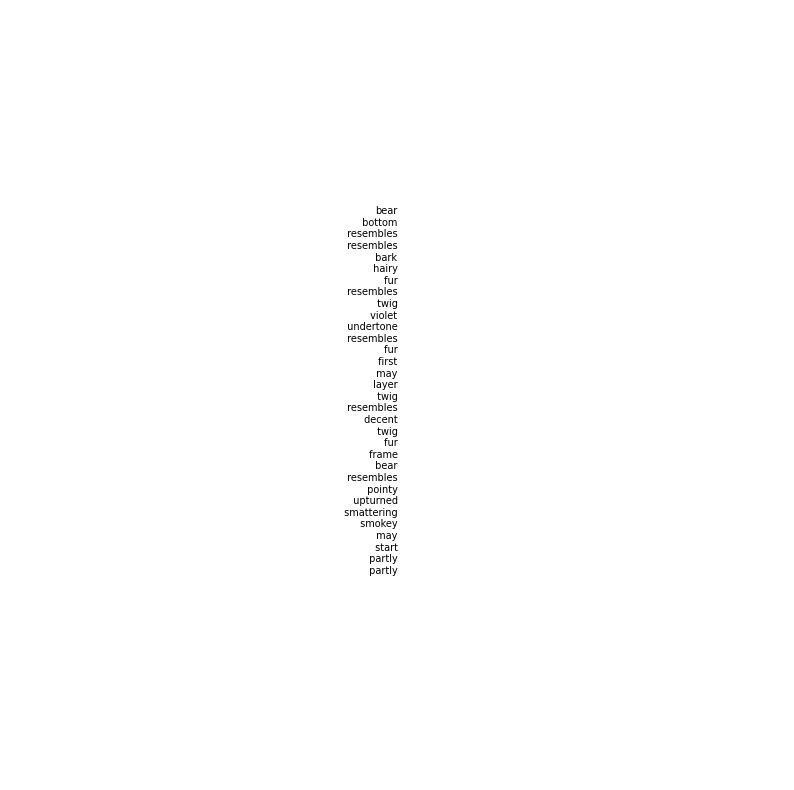

In [14]:

r = recon.reconstruction.squeeze()
numpimage = dataset.plot_text(r,(10,10))


In [15]:
numpimage.shape

torch.Size([3, 1000, 1000])

In [12]:
from multivae.trainers import BaseTrainer, BaseTrainerConfig

trainer_config = BaseTrainerConfig()

trainer = BaseTrainer(
    model = model,
    train_dataset=dataset,
    training_config=trainer_config
)

trainer.train()

/home/asenella/miniconda3/envs/multivaenv/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
! No eval dataset provided ! -> keeping best model on train.

Model passed sanity check !
Ready for training.

Setting the optimizer with learning rate 0.0001
Created dummy_output_dir folder since did not exist.

Created dummy_output_dir/JNF_training_2024-09-13_10-32-43. 
Training config, checkpoints and final model will be saved here.

Training params:
 - max_epochs: 100
 - per_device_train_batch_size: 64
 - per_device_eval_batch_size: 64
 - checkpoint saving every: None
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
Scheduler: Non

KeyboardInterrupt: 